**Using customer retail dataset implement various models and compare them**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
df = pd.read_csv('customer_retail csv file.csv')

In [7]:
df.shape

(234848, 8)

In [8]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234848 entries, 0 to 234847
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    234848 non-null  object 
 1   StockCode    234848 non-null  object 
 2   Description  233957 non-null  object 
 3   Quantity     234848 non-null  int64  
 4   InvoiceDate  234848 non-null  object 
 5   UnitPrice    234848 non-null  float64
 6   CustomerID   168832 non-null  float64
 7   Country      234847 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 14.3+ MB


In [10]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,234848.000000,234848.000000,168832.000000
mean,9.280241,5.105973,15275.769534
std,225.468659,120.322987,1724.742968
min,-74215.000000,0.000000,12346.000000
25%,1.000000,1.250000,13837.000000
50%,3.000000,2.100000,15144.000000
75%,10.000000,4.210000,16814.000000
max,74215.000000,38970.000000,18287.000000


In [11]:
print(df.isnull().sum())

InvoiceNo          0
StockCode          0
Description      891
Quantity           0
InvoiceDate        0
UnitPrice          0
CustomerID     66016
Country            1
dtype: int64


In [12]:
print(df.dtypes)

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object


In [13]:
print(f"Number of unique countries: {df['Country'].nunique()}")

Number of unique countries: 37


In [14]:
print(df['Country'].value_counts().head(10))

Country
United Kingdom    215643
Germany             4183
France              3565
EIRE                2852
Netherlands         1142
Spain               1142
Belgium              887
Switzerland          690
Australia            642
Portugal             623
Name: count, dtype: int64


In [15]:
clean_data = df.copy()

In [16]:
rows_before = clean_data.shape[0]
clean_data = clean_data.dropna(subset=['CustomerID'])
rows_removed = rows_before - clean_data.shape[0]
print("Rows removed because CustomerID was missing:", rows_removed)

Rows removed because CustomerID was missing: 66016


In [17]:
median_quantity = clean_data['Quantity'].median()
clean_data['bought_a_lot'] = (clean_data['Quantity'] > median_quantity).astype(int)

In [18]:
print("Median Quantity:", median_quantity)
print("bought_a_lot value counts:")
print(clean_data['bought_a_lot'].value_counts())

Median Quantity: 5.0
bought_a_lot value counts:
bought_a_lot
0    84929
1    83903
Name: count, dtype: int64


In [19]:
selected_columns = ['Quantity', 'UnitPrice', 'Country']

In [20]:
X = clean_data[selected_columns].copy()
y = clean_data['bought_a_lot'].copy()
print("Input shape (X):", X.shape)
print("Target shape (y):", y.shape)

Input shape (X): (168832, 3)
Target shape (y): (168832,)


In [21]:
from pandas.api.types import is_numeric_dtype

saved_encoders = {}

for column_name in selected_columns:
    if not is_numeric_dtype(X[column_name]):

        encoder = LabelEncoder()
        X[column_name] = encoder.fit_transform(X[column_name].astype(str)).astype('int64')
        saved_encoders[column_name] = encoder
        print(f"Encoded column: {column_name}  ({len(encoder.classes_)} unique values)")

print("After encoding:")
print(X.head())

Encoded column: Country  (36 unique values)
After encoding:
   Quantity  UnitPrice  Country
0         6       2.55       34
1         6       3.39       34
2         8       2.75       34
3         6       3.39       34
4         6       3.39       34


In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=selected_columns)

print("After scaling (first 5 rows):")
print(X_scaled.head())

After scaling (first 5 rows):
   Quantity  UnitPrice   Country
0 -0.024021  -0.012285  0.323076
1 -0.024021  -0.004067  0.323076
2 -0.016355  -0.010328  0.323076
3 -0.024021  -0.004067  0.323076
4 -0.024021  -0.004067  0.323076


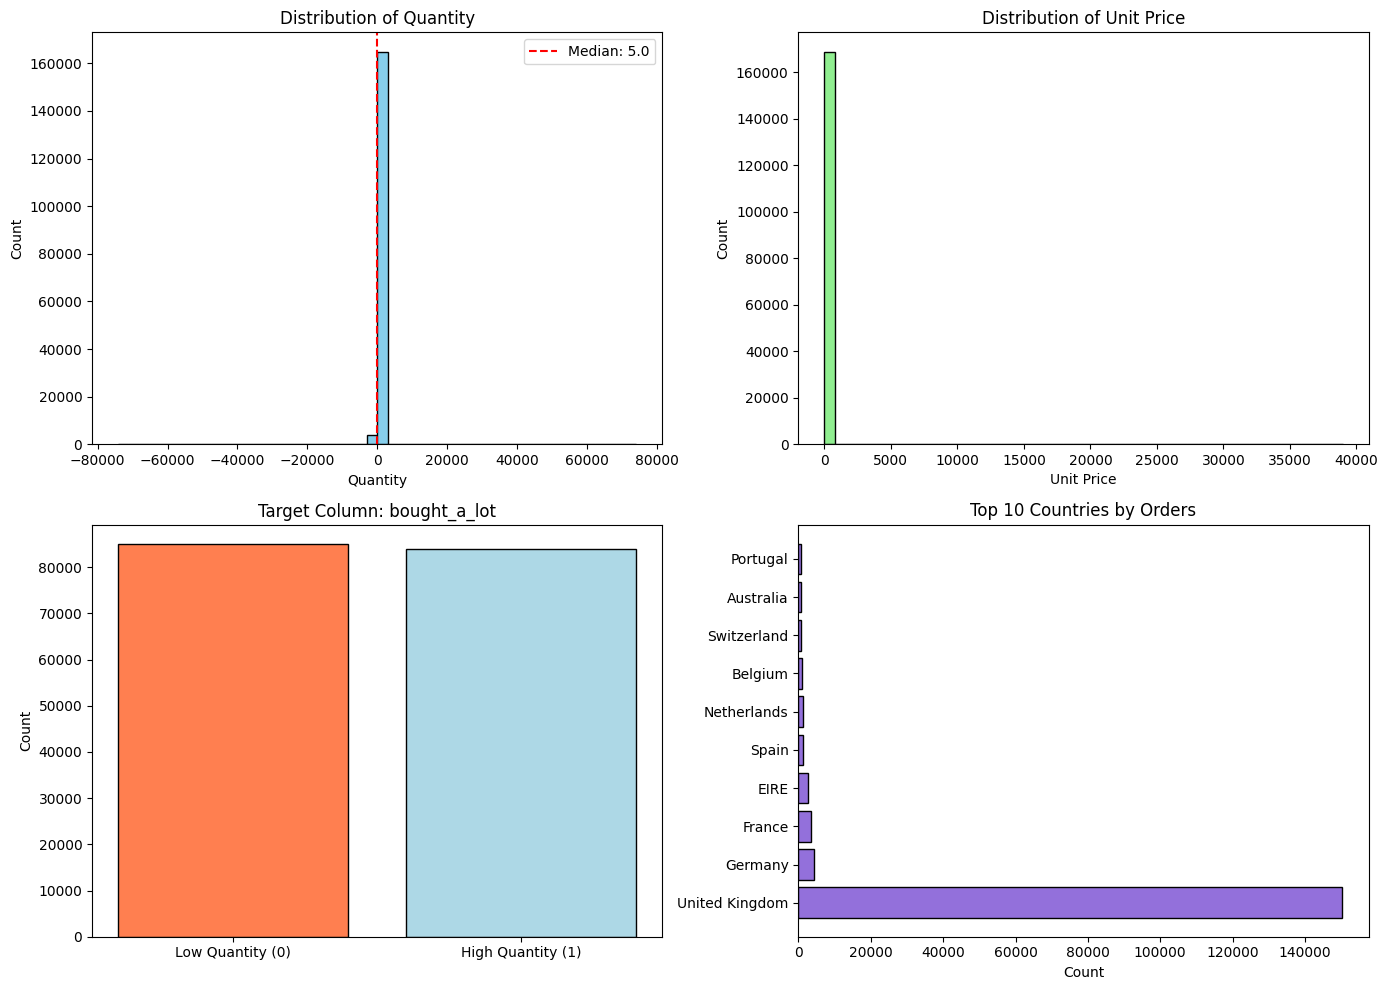

In [24]:
fig, charts = plt.subplots(2, 2, figsize=(14, 10))

charts[0, 0].hist(clean_data['Quantity'], bins=50, color='skyblue', edgecolor='black')
charts[0, 0].set_title('Distribution of Quantity')
charts[0, 0].set_xlabel('Quantity')
charts[0, 0].set_ylabel('Count')
charts[0, 0].axvline(median_quantity, color='red', linestyle='--', label=f'Median: {median_quantity}')
charts[0, 0].legend()

charts[0, 1].hist(clean_data['UnitPrice'], bins=50, color='lightgreen', edgecolor='black')
charts[0, 1].set_title('Distribution of Unit Price')
charts[0, 1].set_xlabel('Unit Price')
charts[0, 1].set_ylabel('Count')

target_counts = y.value_counts()
charts[1, 0].bar(['Low Quantity (0)', 'High Quantity (1)'],
                 target_counts.values,
                 color=['coral', 'lightblue'],
                 edgecolor='black')
charts[1, 0].set_title('Target Column: bought_a_lot')
charts[1, 0].set_ylabel('Count')

top_countries = clean_data['Country'].value_counts().head(10)
charts[1, 1].barh(range(len(top_countries)), top_countries.values, color='mediumpurple', edgecolor='black')
charts[1, 1].set_yticks(range(len(top_countries)))
charts[1, 1].set_yticklabels(top_countries.index)
charts[1, 1].set_title('Top 10 Countries by Orders')
charts[1, 1].set_xlabel('Count')

plt.tight_layout()
plt.show()
plt.close()


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])

Training rows: 135065
Testing rows : 33767


In [26]:
# Logistic_Regression Train
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_predictions_train = lr_model.predict(X_train)
lr_predictions_test  = lr_model.predict(X_test)

print("Logistic Regression trained")

Logistic Regression trained


In [27]:
# Decision Tree Train
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)

dt_model.fit(X_train, y_train)

dt_predictions_train = dt_model.predict(X_train)
dt_predictions_test  = dt_model.predict(X_test)

print("Decision Tree trained")

Decision Tree trained


In [28]:
# KNN (K-Nearest Neighbors) Train
knn_model = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_model.fit(X_train, y_train)

knn_predictions_train = knn_model.predict(X_train)
knn_predictions_test  = knn_model.predict(X_test)

print("KNN trained")

KNN trained


In [33]:
# Logistic Regression accuracy
lr_train_accuracy = accuracy_score(y_train, lr_predictions_train)
lr_test_accuracy  = accuracy_score(y_test,  lr_predictions_test)

# Decision Tree accuracy
dt_train_accuracy = accuracy_score(y_train, dt_predictions_train)
dt_test_accuracy  = accuracy_score(y_test,  dt_predictions_test)

# KNN accuracy
knn_train_accuracy = accuracy_score(y_train, knn_predictions_train)
knn_test_accuracy  = accuracy_score(y_test,  knn_predictions_test)

print("\n--- Accuracy Results ---")
print(f"Logistic Regression  — Train: {lr_train_accuracy:.4f}   Test: {lr_test_accuracy:.4f}")
print(f"Decision Tree        — Train: {dt_train_accuracy:.4f}   Test: {dt_test_accuracy:.4f}")
print(f"KNN                  — Train: {knn_train_accuracy:.4f}   Test: {knn_test_accuracy:.4f}")


--- Accuracy Results ---
Logistic Regression  — Train: 0.9818   Test: 0.9805
Decision Tree        — Train: 1.0000   Test: 1.0000
KNN                  — Train: 0.9993   Test: 0.9988


In [34]:
# Confusion matrix for each model
lr_conf_matrix  = confusion_matrix(y_test, lr_predictions_test)
dt_conf_matrix  = confusion_matrix(y_test, dt_predictions_test)
knn_conf_matrix = confusion_matrix(y_test, knn_predictions_test)

print("\nClassification Report — Logistic Regression:")
print(classification_report(y_test, lr_predictions_test, target_names=['Low Quantity', 'High Quantity']))

print("Classification Report — Decision Tree:")
print(classification_report(y_test, dt_predictions_test, target_names=['Low Quantity', 'High Quantity']))

print("Classification Report — KNN:")
print(classification_report(y_test, knn_predictions_test, target_names=['Low Quantity', 'High Quantity']))


Classification Report — Logistic Regression:
               precision    recall  f1-score   support

 Low Quantity       0.97      1.00      0.98     16986
High Quantity       1.00      0.96      0.98     16781

     accuracy                           0.98     33767
    macro avg       0.98      0.98      0.98     33767
 weighted avg       0.98      0.98      0.98     33767

Classification Report — Decision Tree:
               precision    recall  f1-score   support

 Low Quantity       1.00      1.00      1.00     16986
High Quantity       1.00      1.00      1.00     16781

     accuracy                           1.00     33767
    macro avg       1.00      1.00      1.00     33767
 weighted avg       1.00      1.00      1.00     33767

Classification Report — KNN:
               precision    recall  f1-score   support

 Low Quantity       1.00      1.00      1.00     16986
High Quantity       1.00      1.00      1.00     16781

     accuracy                           1.00     3376

In [35]:
models = ['Logistic Regression', 'Decision Tree', 'KNN']

train_acc = [lr_train_accuracy, dt_train_accuracy, knn_train_accuracy]
test_acc  = [lr_test_accuracy, dt_test_accuracy, knn_test_accuracy]


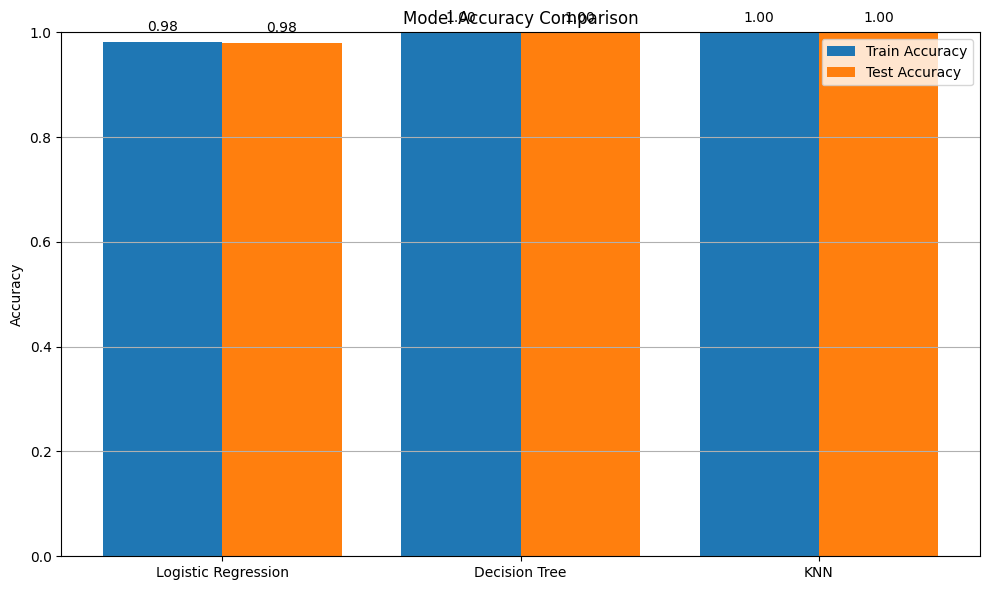

In [36]:
x = np.arange(len(models))

plt.figure(figsize=(10, 6))
plt.bar(x - 0.2, train_acc, width=0.4, label='Train Accuracy')
plt.bar(x + 0.2, test_acc, width=0.4, label='Test Accuracy')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(x, models)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y')
for i in range(len(models)):
    plt.text(i - 0.2, train_acc[i] + 0.02, f"{train_acc[i]:.2f}", ha='center')
    plt.text(i + 0.2, test_acc[i] + 0.02, f"{test_acc[i]:.2f}", ha='center')

plt.tight_layout()
plt.show()

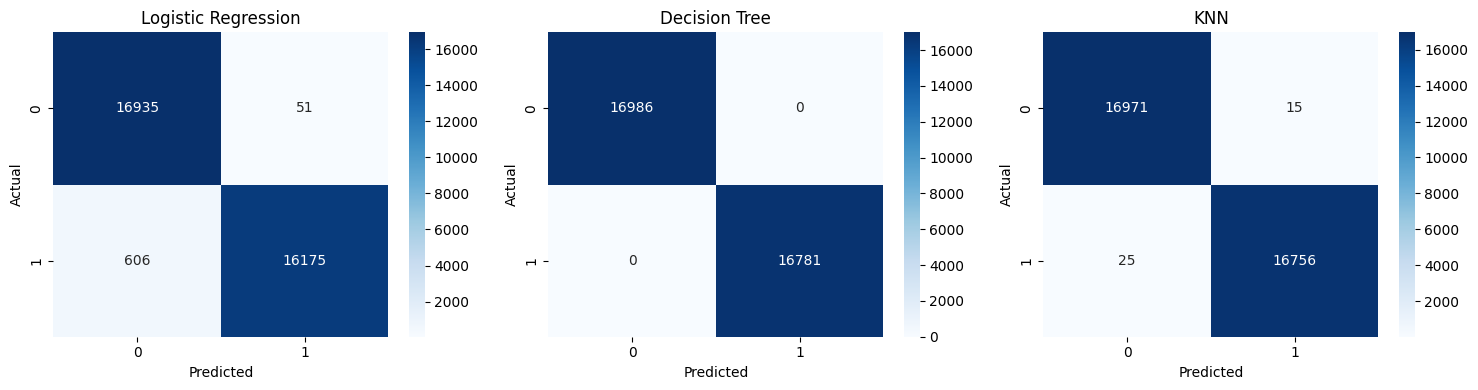

In [37]:
models = ['Logistic Regression', 'Decision Tree', 'KNN']
conf_matrices = [lr_conf_matrix, dt_conf_matrix, knn_conf_matrix]

plt.figure(figsize=(15, 4))

for i in range(3):
    plt.subplot(1, 3, i+1)

    sns.heatmap(conf_matrices[i],
                annot=True,
                fmt='d',
                cmap='Blues')

    plt.title(models[i])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()